In [16]:
from google.colab import files

uploaded = files.upload()

Saving image_smpl.obj to image_smpl (8).obj


In [17]:
import trimesh
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d.art3d import Poly3DCollection


In [18]:
mesh = trimesh.load("image_smpl.obj")
angle = np.radians(15)
rotation_matrix = trimesh.transformations.rotation_matrix(
    angle,
    [1, 0, 0]
)

mesh.apply_transform(rotation_matrix)

print("Mesh Loaded Successfully!\n")

print("Mesh Bounds:")
print(mesh.bounds)


Mesh Loaded Successfully!

Mesh Bounds:
[[-0.4460701  -0.949651   -0.38326269]
 [ 0.47041982  0.80945493  0.3607178 ]]


In [19]:
waist_y = 0.1

In [20]:
section = mesh.section(
    plane_origin=[0, waist_y, 0],
    plane_normal=[0, 1, 0]
)

if section is None:
    raise ValueError("No intersection found at this height!")

curves = section.discrete

print("\nNumber of contours found:", len(curves))



Number of contours found: 3


In [24]:
best_curve = None
best_length = 0

for curve in curves:
    closed_curve = np.vstack([curve, curve[0]])

    length = np.sum(
        np.linalg.norm(
            np.diff(closed_curve, axis=0),
            axis=1
        )
    )

    if length > best_length:

        best_length = length
        best_curve = closed_curve





Waist Circumference: 1.0747
Waist Height (Y): 0.1


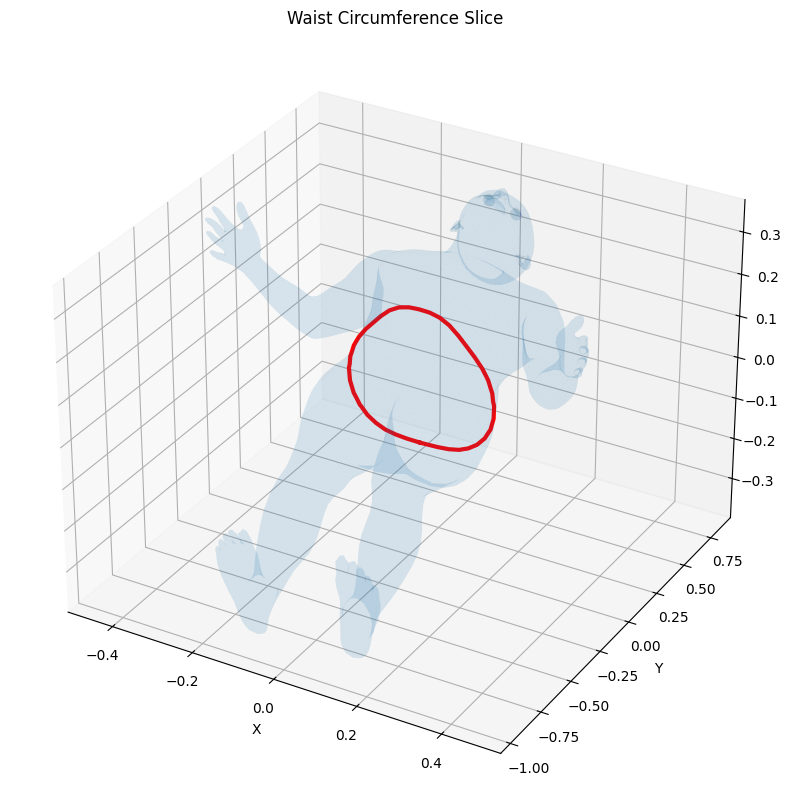

In [25]:
print("\n====================================")
print("Waist Circumference:", round(best_length, 4))
print("Waist Height (Y):", waist_y)
print("====================================")
fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(111, projection='3d')


triangles = mesh.vertices[mesh.faces]

mesh_collection = Poly3DCollection(
    triangles,
    alpha=0.08
)

ax.add_collection3d(mesh_collection)


ax.plot(
    best_curve[:, 0],
    best_curve[:, 1],
    best_curve[:, 2],
    color='red',
    linewidth=3
)

x = mesh.vertices[:, 0]
y = mesh.vertices[:, 1]
z = mesh.vertices[:, 2]

ax.auto_scale_xyz(x, y, z)



ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.title("Waist Circumference Slice")

plt.show()